## VIIRS assimilation experience


Inputs

In [1]:
from edelassim.observations import EdelweissGrandesRoussesGrid

data_folder = "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses"
simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m"
period = slice("2022-02-01", "2022-06-01")
grandesrousses_grid = EdelweissGrandesRoussesGrid()

In [3]:
import xarray as xr
from edelassim.bdclim import crop_bdclim, find_station_locations

forest_mask_path = f"{data_folder}/forest_mask/corine_grandesrousses_max.nc"
forest_mask = xr.open_dataarray(forest_mask_path, engine="rasterio").sel(band=1).drop_vars("band")

no_assim_all_path = f"{simulation_folder}/open_loop/all_members/pro/PRO_GrandesRousses250m_2021080206_2022080106.nc"
edel = (xr.open_dataset(no_assim_all_path).where(forest_mask == 0).sel(time=period)).data_vars["DSN_T_ISBA"]

assim_all_path = f"{simulation_folder}/TEST_assim_viirs/all_members/pro/PRO.nc"
edel_assim = (xr.open_dataset(assim_all_path).where(forest_mask == 0).sel(time=period)).data_vars["DSN_T_ISBA"]

pleiades_path = f"{data_folder}/pleiades_time_series/pleaides_granderousses_all.nc"
pleiades = (xr.open_dataset(pleiades_path).where(forest_mask == 0).sel(time=period)).data_vars["snow_depth"]

bdclim_path = "/home/imperatoren/work/edelweiss_assimilation/data/snow_depth/bdclim/snow_depth_bdclim.nc"
bdclim = crop_bdclim(bdclim_path, grid=grandesrousses_grid).data_vars["neigetotx"].sel(time=period) / 100
x_poste, y_poste = find_station_locations(bdclim_dataset=bdclim)

/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encou

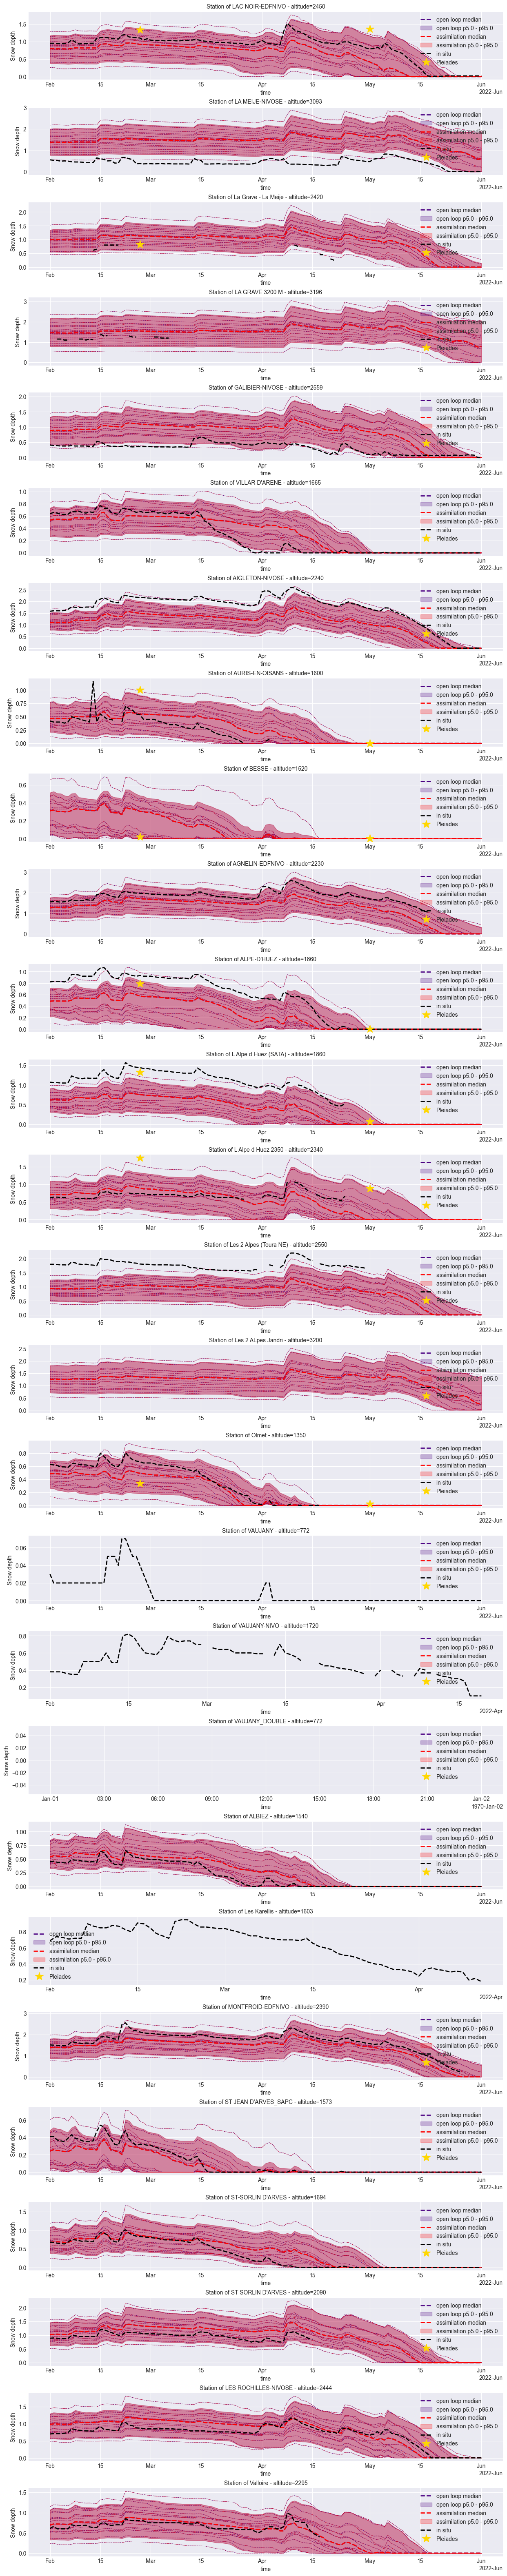

In [4]:
# EXPERIENCE VIIRS
import matplotlib.pyplot as plt


plt.style.use("seaborn-v0_8-darkgrid")
n_tot = bdclim.sizes["num_poste"]
# n_tot = 5
fig, axs = plt.subplots(n_tot, 1, figsize=(15, 3 * n_tot))
fig.subplots_adjust(hspace=0.4)
time = edel.coords["time"]
qmin, qmax = 0.05, 0.95
for pp in range(n_tot):
    ax = axs[pp]
    xi, yi = x_poste[pp], y_poste[pp]
    open_loop_sd_median = edel.sel(x=xi, y=yi, method="nearest").median(dim="member")
    open_loop_sd_p5 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=qmin, dim="member")
    open_loop_sd_p95 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=qmax, dim="member")

    assim_sd_median = edel_assim.sel(x=xi, y=yi, method="nearest").median(dim="member")
    assim_sd_qmin = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=qmin, dim="member")
    assim_sd_qmax = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=qmax, dim="member")

    bdclim_poste = bdclim.where(bdclim["x"] == xi, drop=True).where(bdclim["y"] == yi, drop=True)
    pleiades_obs = pleiades.sel(x=xi, y=yi, method="nearest")

    open_loop_until_assim = edel.sel()
    ax.plot(time, open_loop_sd_median, color="indigo", linestyle="dashed", linewidth=2, label="open loop median")
    edel.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, color="indigo", linestyle="dashed", linewidth=0.6)
    ax.fill_between(
        time, open_loop_sd_p5, open_loop_sd_p95, color="indigo", alpha=0.25, label=f"open loop p{qmin * 100} - p{qmax * 100}"
    )

    ax.plot(
        edel_assim.coords["time"], assim_sd_median, color="red", linestyle="dashed", linewidth=2, label="assimilation median"
    )
    edel_assim.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, linestyle="dotted", color="r", linewidth=0.6)
    ax.fill_between(
        edel_assim.coords["time"],
        assim_sd_qmin,
        assim_sd_qmax,
        color="red",
        alpha=0.25,
        label=f"assimilation p{qmin * 100} - p{qmax * 100}",
    )

    ax.plot(time, bdclim_poste.values, color="black", linestyle="dashed", linewidth=2, label="in situ")
    ax.plot(pleiades_obs.time, pleiades_obs.values, marker="*", linewidth=0, markersize=15, color="gold", label="Pleiades")
    ax.legend()
    ax.set_ylabel("Snow depth")
    ax.set_title(
        f"Station of {bdclim_poste.coords['Station_Name'].values[0]} - altitude={bdclim_poste.coords['ZS'].values[0]}",
        fontsize=10,
    )
    ax.grid(True)

/home/imperatoren/miniforge3/envs/viirs_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/miniforge3/envs/viirs_env/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


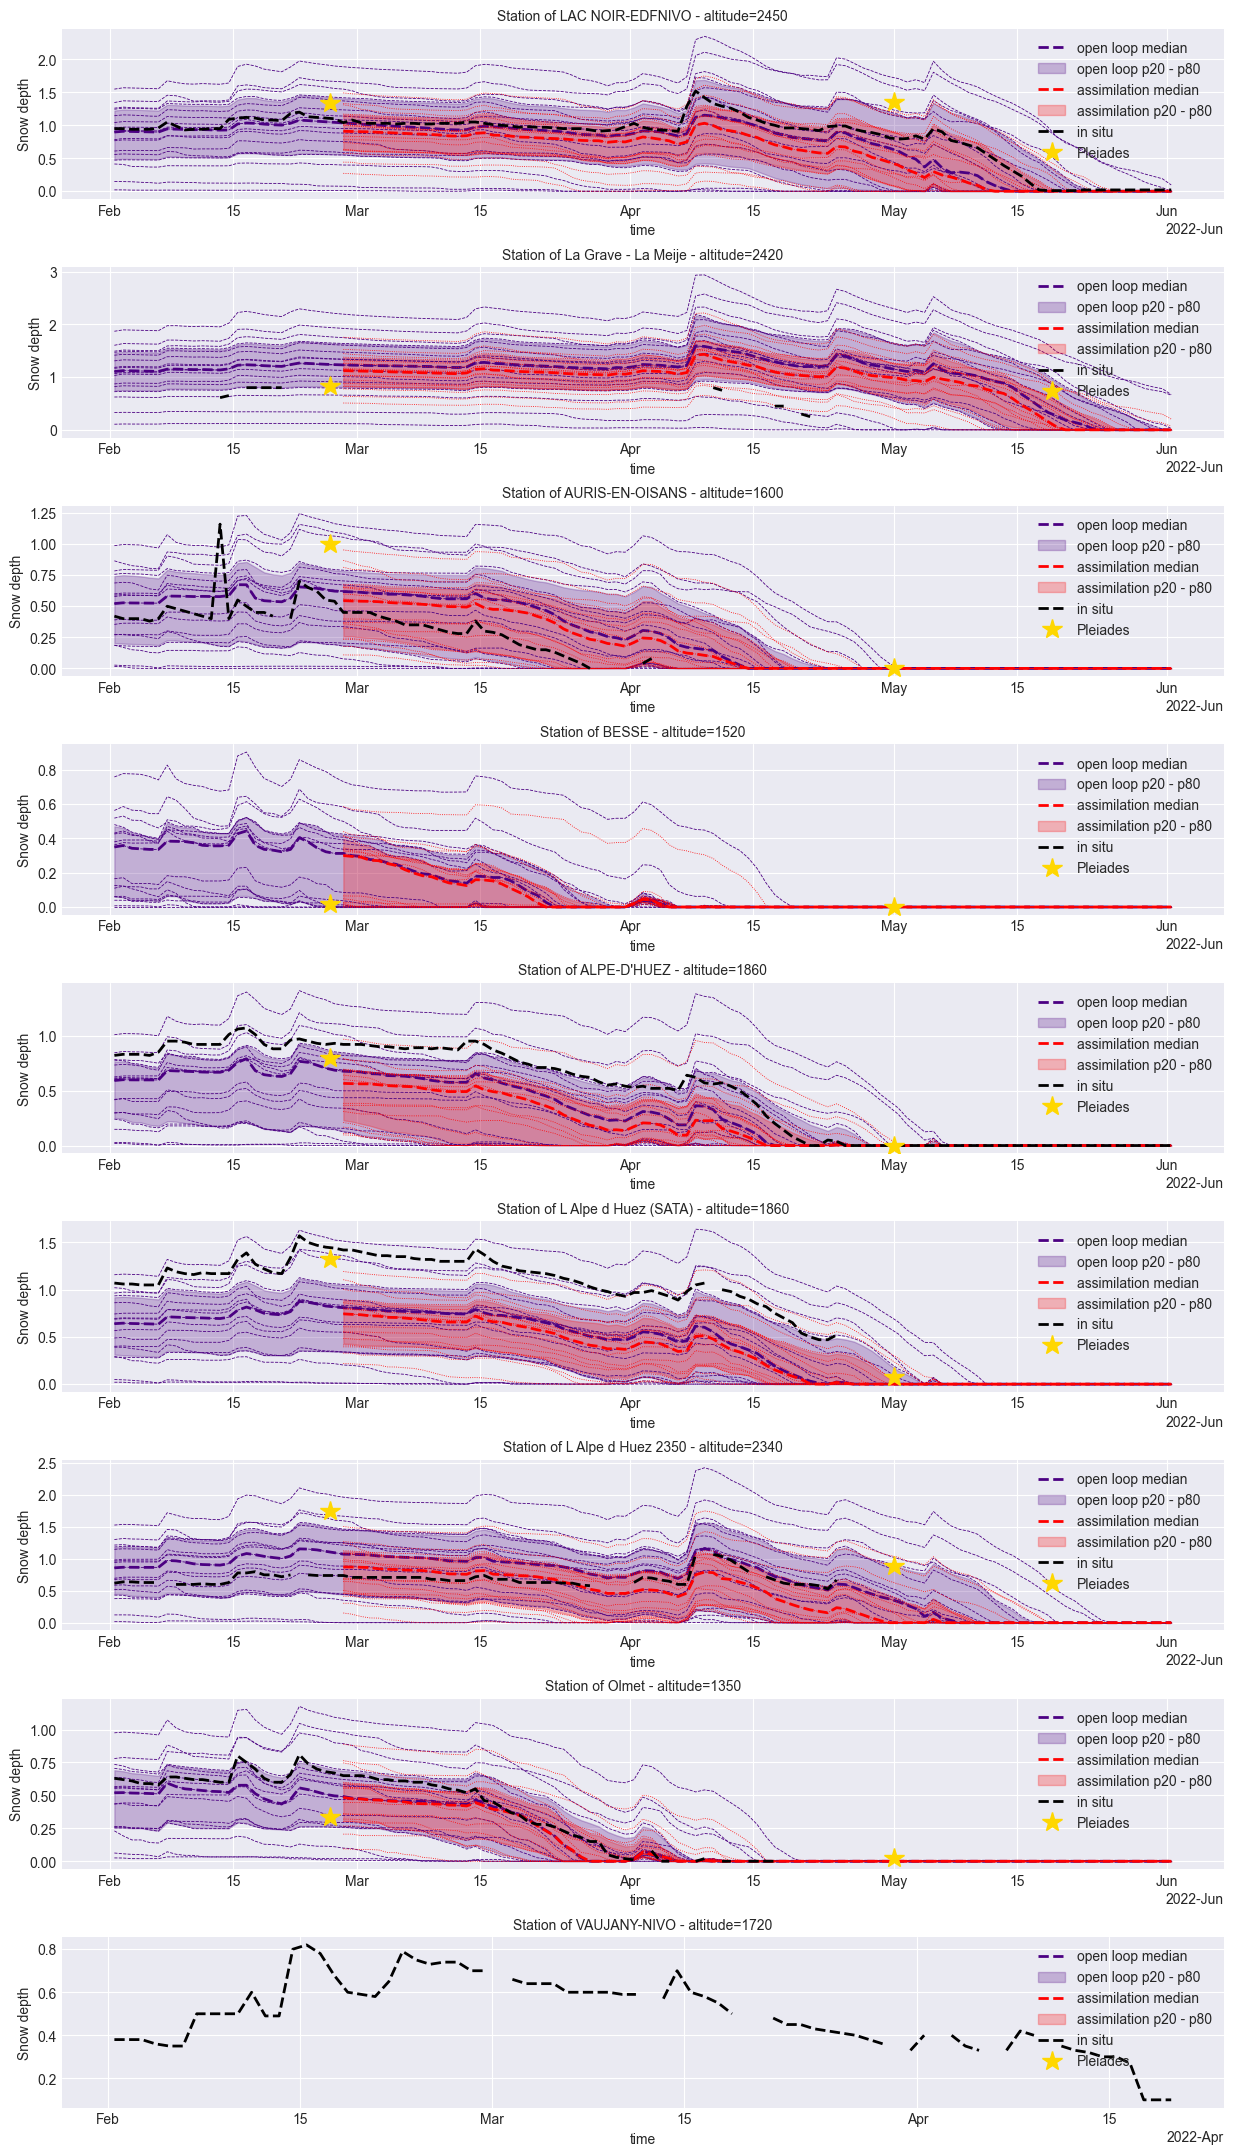

In [ ]:
# EXPERIENCE VIIRS
import matplotlib.pyplot as plt


plt.style.use("seaborn-v0_8-darkgrid")
n_tot = bdclim.sizes["num_poste"]
# n_tot = 5
fig, axs = plt.subplots(n_tot, 1, figsize=(15, 3 * n_tot))
fig.subplots_adjust(hspace=0.4)
time = edel.coords["time"]
for pp in range(n_tot):
    ax = axs[pp]
    xi, yi = x_poste[pp], y_poste[pp]
    open_loop_sd_median = edel.sel(x=xi, y=yi, method="nearest").median(dim="member")
    open_loop_sd_p5 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=0.2, dim="member")
    open_loop_sd_p95 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=0.8, dim="member")

    assim_sd_median = edel_assim.sel(x=xi, y=yi, method="nearest").median(dim="member")
    assim_sd_p5 = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=0.2, dim="member")
    assim_sd_p95 = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=0.8, dim="member")

    bdclim_poste = bdclim.where(bdclim["x"] == xi, drop=True).where(bdclim["y"] == yi, drop=True)
    pleiades_obs = pleiades.sel(x=xi, y=yi, method="nearest")

    # open_loop_until_assim = edel.sel()
    ax.plot(time, open_loop_sd_median, color="indigo", linestyle="dashed", linewidth=2, label="open loop median")
    edel.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, color="indigo", linestyle="dashed", linewidth=0.6)
    ax.fill_between(time, open_loop_sd_p5, open_loop_sd_p95, color="indigo", alpha=0.25, label="open loop p20 - p80")

    ax.plot(
        edel_assim.coords["time"], assim_sd_median, color="red", linestyle="dashed", linewidth=2, label="assimilation median"
    )
    edel_assim.sel(x=xi, y=yi, method="nearest").plot.line(x="time", ax=ax, linestyle="dotted", color="r", linewidth=0.6)
    ax.fill_between(
        edel_assim.coords["time"], assim_sd_p5, assim_sd_p95, color="red", alpha=0.25, label="assimilation p20 - p80"
    )

    ax.plot(time, bdclim_poste.values, color="black", linestyle="dashed", linewidth=2, label="in situ")
    ax.plot(pleiades_obs.time, pleiades_obs.values, marker="*", linewidth=0, markersize=15, color="gold", label="Pleiades")
    ax.legend()
    ax.set_ylabel("Snow depth")
    ax.set_title(
        f"Station of {bdclim_poste.coords['Station_Name'].values[0]} - altitude={bdclim_poste.coords['ZS'].values[0]}",
        fontsize=10,
    )
    ax.grid(True)
